<a href="https://colab.research.google.com/github/Khaylaasyas28/UTS-DATMING-Khayla-Syahda-Revani-144/blob/main/UTS_Data_Mining_Khayla_Syahda_144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

Library yang digunakan berfungsi untuk membantu proses analisis data, visualisasi, preprocessing, pembangunan model machine learning, hingga evaluasi model klasifikasi.

In [2]:
train = pd.read_csv("data_training.csv")
test = pd.read_csv("data_testing.csv")

Dataset training digunakan untuk melatih model karena memiliki variabel target yaitu quality, sedangkan dataset testing digunakan untuk melakukan prediksi kualitas wine pada data yang belum memiliki label.

In [3]:
display(train.head())
display(test.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Tahap ini dilakukan untuk melihat beberapa data pertama dari dataset agar dapat memahami struktur data, nama variabel, dan isi dari masing-masing kolom.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [5]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Tahap ini bertujuan untuk mengetahui jumlah data, tipe data setiap variabel, serta memastikan bahwa data siap digunakan dalam proses analisis dan pemodelan.

In [6]:
print(train.isnull().sum())
print(test.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Pengecekan missing value dilakukan untuk memastikan tidak terdapat data kosong yang dapat memengaruhi performa model. Jika ditemukan missing value, maka dilakukan penanganan dengan imputasi menggunakan nilai median.

In [7]:
print(train.duplicated().sum())

0


Pengecekan data duplikat dilakukan untuk memastikan tidak terdapat data yang berulang, karena data duplikat dapat menyebabkan model belajar pola yang bias.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

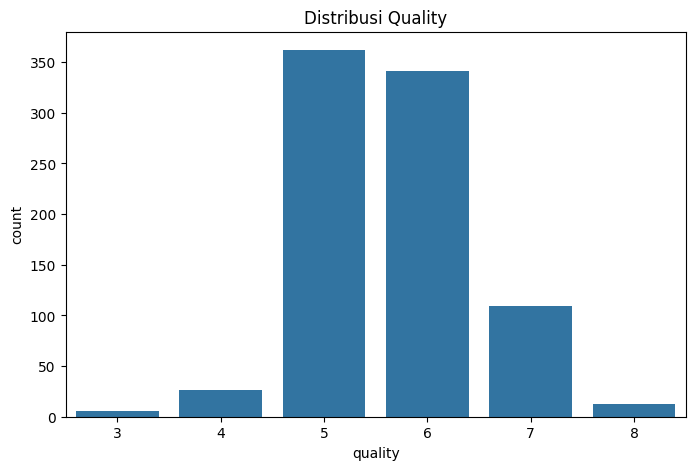

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train)
plt.title("Distribusi Quality")
plt.show()

Visualisasi distribusi quality dilakukan untuk mengetahui persebaran kelas kualitas wine dalam dataset. Dari grafik ini dapat diketahui kelas quality mana yang memiliki jumlah data paling dominan.

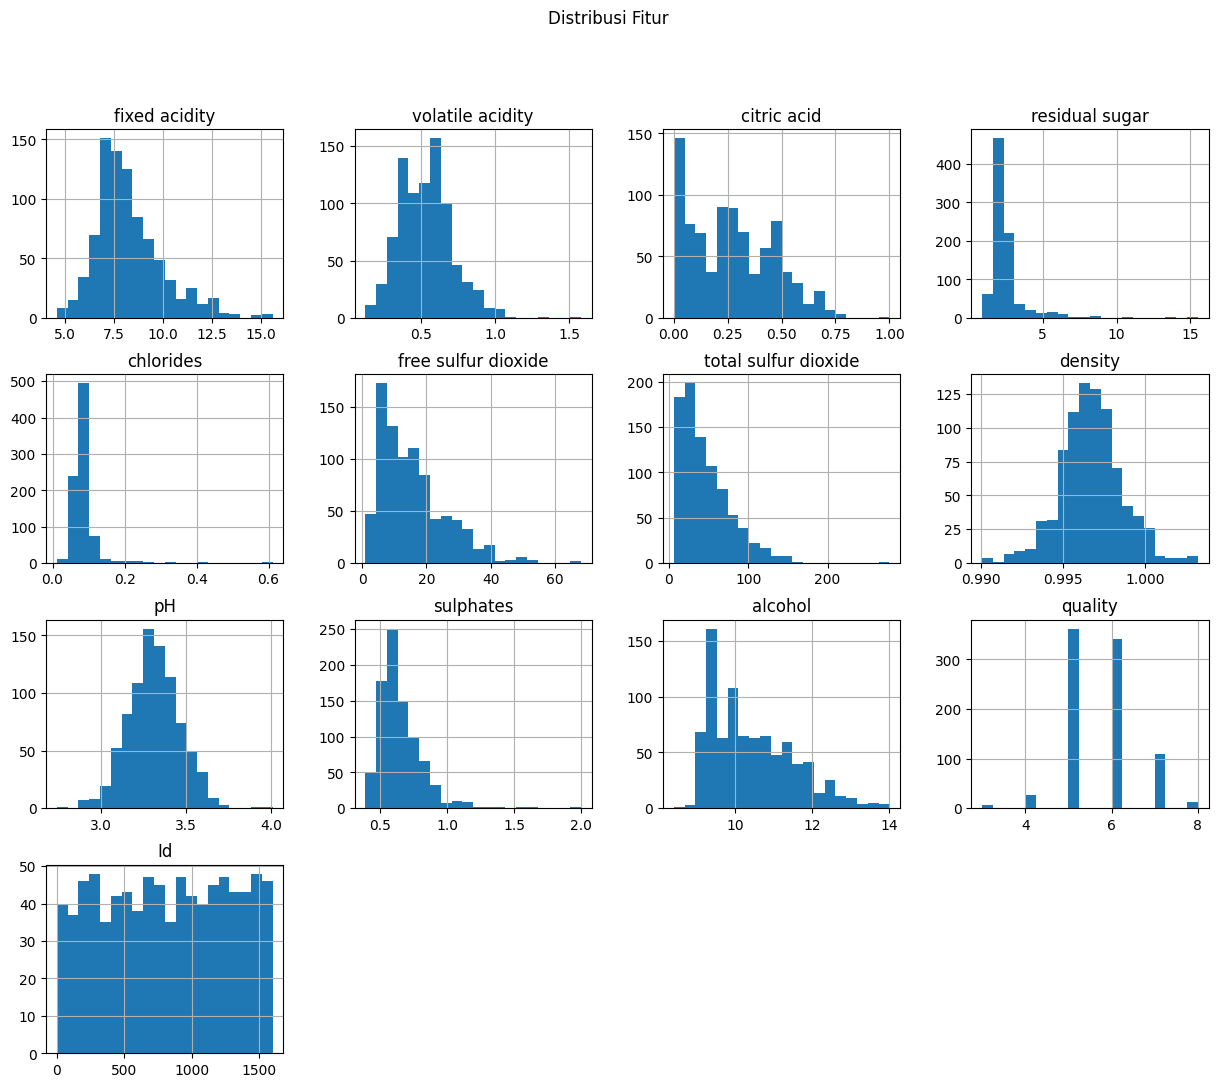

In [10]:
train.hist(figsize=(15,12), bins=20)
plt.suptitle("Distribusi Fitur")
plt.show()

Histogram digunakan untuk melihat distribusi masing-masing variabel numerik, sehingga dapat diketahui pola penyebaran data serta kemungkinan adanya skewness atau distribusi yang tidak merata.

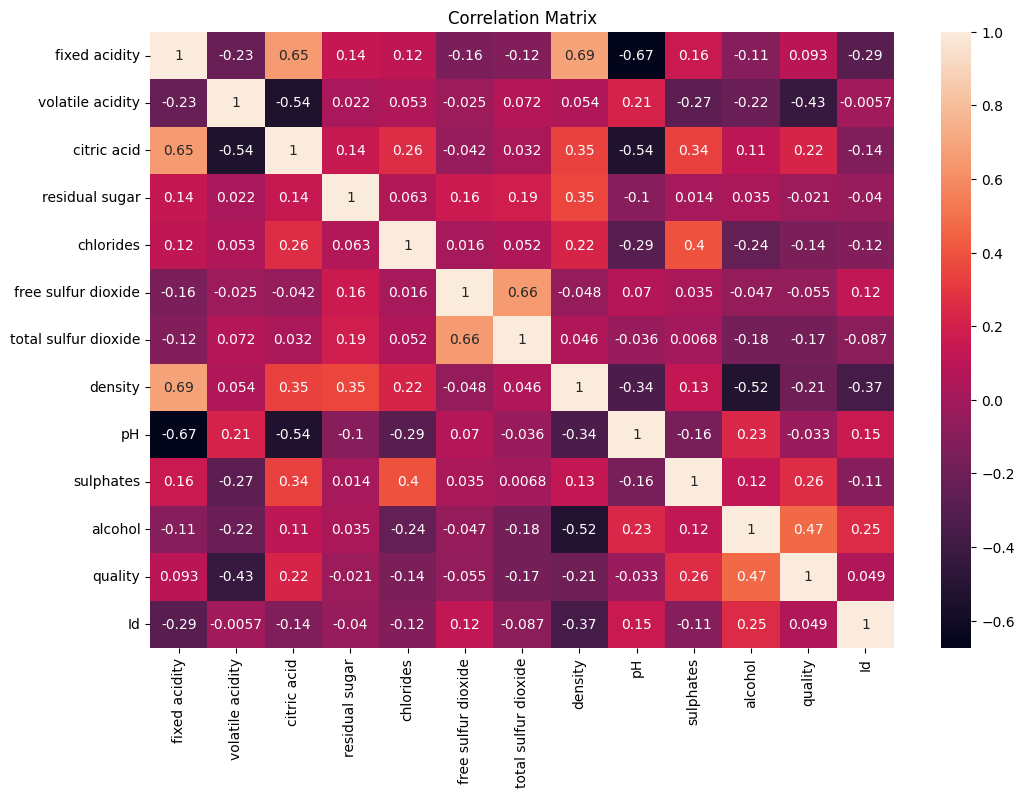

In [11]:
plt.figure(figsize=(12,8))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

Heatmap korelasi digunakan untuk mengetahui hubungan antar variabel dalam dataset. Nilai korelasi yang tinggi menunjukkan adanya hubungan yang kuat antar fitur.

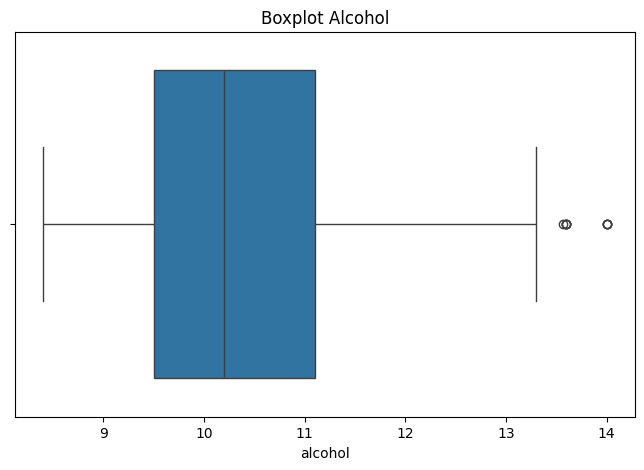

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=train['alcohol']
)

plt.title("Boxplot Alcohol")
plt.show()

Boxplot digunakan untuk mendeteksi keberadaan outlier atau nilai ekstrim pada variabel, sehingga dapat membantu memahami karakteristik data sebelum proses modeling.

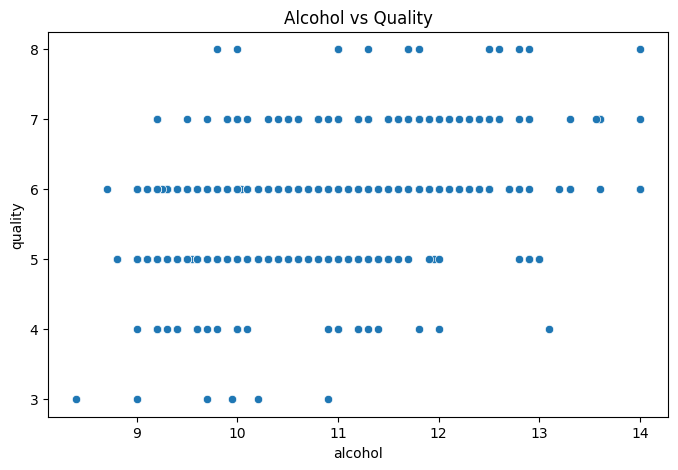

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='alcohol',
    y='quality',
    data=train
)

plt.title("Alcohol vs Quality")
plt.show()

Scatter plot digunakan untuk melihat hubungan antara salah satu fitur, seperti alcohol, dengan variabel target quality. Dari visualisasi ini dapat diamati pola hubungan antar variabel.

In [14]:
test_id = test['Id']

X = train.drop(['Id', 'quality'], axis=1)
y = train['quality']

X_test = test.drop('Id', axis=1)

Pada tahap ini data dipisahkan menjadi variabel input (feature) dan variabel target (quality). Variabel input digunakan sebagai prediktor, sedangkan variabel target digunakan sebagai label klasifikasi.

In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dataset training dibagi menjadi data latih dan data validasi. Data latih digunakan untuk membangun model, sedangkan data validasi digunakan untuk menguji performa model.

In [16]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

Scaling dilakukan untuk menyamakan skala antar variabel, karena setiap fitur memiliki rentang nilai yang berbeda. Hal ini membantu model dalam mempelajari pola data dengan lebih optimal.

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Pada tahap ini model Random Forest dilatih menggunakan data training untuk mempelajari pola hubungan antara fitur kimia wine dengan kualitas wine.

In [18]:
pred_valid = model.predict(X_valid_scaled)

print("Akurasi:", accuracy_score(y_valid, pred_valid))

Akurasi: 0.6046511627906976


Accuracy digunakan untuk mengukur tingkat ketepatan model dalam melakukan prediksi. artinya model memiliki tingkat ketepatan prediksi sebesar 60%.

Evaluasi model dilakukan untuk mengetahui seberapa baik model dalam mengklasifikasikan kualitas wine berdasarkan data validasi. Nilai akurasi menunjukkan tingkat ketepatan prediksi model.

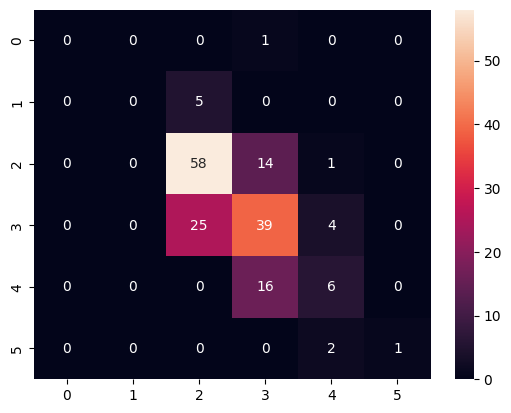

In [19]:
cm = confusion_matrix(y_valid, pred_valid)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

Confusion matrix digunakan untuk melihat detail hasil klasifikasi, yaitu jumlah prediksi yang benar maupun salah pada masing-masing kelas quality.

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, pred_valid))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.79      0.72        73
           6       0.56      0.57      0.57        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.45      0.33      0.35       172
weighted avg       0.58      0.60      0.58       172



Classification report digunakan untuk mengevaluasi performa model secara detail menggunakan precision, recall, dan f1-score.

Precision Mengukur ketepatan hasil prediksi model.

Recall Mengukur kemampuan model menemukan data yang benar.

F1-score Rata-rata harmonis precision dan recall.

Semakin mendekati 1: ➡️ performa model semakin baik.

In [21]:
prediksi_quality = model.predict(X_test_scaled)

In [23]:
hasil_prediksi = pd.DataFrame({
    'Id': test_id,
    'quality': prediksi_quality
})

# Menyimpan ke file CSV
hasil_prediksi.to_csv(
    "hasilprediksi_144.csv",
    index=False
)

print("File hasil prediksi berhasil disimpan")

File hasil prediksi berhasil disimpan


In [25]:
from google.colab import files

# Download file CSV di Google Colab

files.download("hasilprediksi_144.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model yang telah dilatih kemudian digunakan untuk memprediksi nilai quality pada dataset testing yang belum memiliki label.

In [26]:
hasil_prediksi = pd.DataFrame({
    'Id': test_id,
    'quality': prediksi_quality
})

display(hasil_prediksi)

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,6


In [27]:
hasil_prediksi.to_csv('hasilprediksi_144.csv', index=False)
df = pd.read_csv('hasilprediksi_144.csv')
df

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,6
